# Assignment 3 — STL-10: LeNet-5 & ZFNet

Computer Vision · Deep Learning for Computer Vision

---

## Notebook overview

This notebook is written as a **project analysis and explanation notebook**. Instead of being only a place to execute cells, it is meant to explain the motivation, structure, and results of the assignment in a narrative way.

Read it as a guided answer to the project itself:

- what the STL-10 dataset looks like,
- why LeNet-5 is used as the lightweight baseline,
- why a deeper ZFNet-style model is tested as the stronger alternative, and
- what the final training curves suggest about model capacity and generalization.

| Artifact          | Role                                                                      |
| ----------------- | ------------------------------------------------------------------------- |
| `lenet5.py`       | Baseline CNN architecture, STL-10 preprocessing, training, and plotting. |
| `zfnet.py`        | Deeper CNN architecture, training utilities, and model-comparison tools. |
| `main.py`         | Optional command-line entry point for batch runs.                         |
| **This notebook** | Explanatory walkthrough of the experiment design and the project results. |

**Dataset:** [STL-10](https://cs.stanford.edu/~acoates/stl10/) — 5k train / 8k test, 96×96 RGB images across 10 classes. In this project, LeNet uses **32×32** resized inputs as a compact baseline, while ZFNet uses **64×64** inputs so the deeper network keeps more spatial detail.

A useful way to read the notebook is to focus on three project questions:

1. What kind of baseline does LeNet-5 establish on STL-10?
2. How much does a deeper ZFNet-style architecture improve on that baseline?
3. What do the loss and accuracy curves reveal about the strengths and limits of each model?


## 1. Environment

Use the project `venv` and install dependencies once:

```bash
python3 -m venv venv
source venv/bin/activate
pip install -r requirements.txt
```

Open this notebook with the **same interpreter** (`venv`) as the kernel. That matters because the notebook imports the local project modules directly, so the analysis only makes sense if it is running against the same code and package versions used throughout the project.

If the kernel is configured correctly, the notebook should be able to:

- import `lenet5.py` and `zfnet.py` without path issues,
- download or reuse STL-10 under `data/`, and
- save figures and JSON histories under `outputs/` for later discussion.


In [1]:
%matplotlib inline

import json
import os

import torch

# Import the reusable training pipelines from the project modules.
from lenet5 import (
    LeNet5,
    get_stl10_loaders,
    train_model as train_lenet,
    plot_training_curves as plot_lenet_curves,
    count_parameters as count_lenet_params,
)
from zfnet import (
    ZFNet,
    get_stl10_loaders_zfnet,
    train_model as train_zfnet,
    plot_training_curves as plot_zf_curves,
    compare_architectures,
    count_parameters as count_zf_params,
)

# Keep the notebook deterministic enough for model-to-model comparison.
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Save analysis artifacts in the project output folders.
os.makedirs("outputs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

[INFO] Using device: cpu
[INFO] Using device: cpu
Device: cpu


## 2. Project framing and experiment settings

This assignment studies the same classification problem with two different convolutional networks so the trade-off in model capacity is easy to see.

- **LeNet-5** is the intentionally small baseline: fast, simple, and useful for establishing what a lightweight CNN can do on STL-10.
- **ZFNet** is the stronger comparison model: deeper, wider, and better suited to higher-resolution visual structure.

The cells below use one consistent project setup so the results stay comparable across models. That makes the notebook useful not just for running code, but for explaining why one architecture succeeds more clearly than the other.

Keep an eye on three experimental choices as you read:

1. the input resolution each model receives,
2. the optimizer and scheduler paired with each architecture, and
3. how quickly each model's validation behavior stabilizes.


In [2]:
# Project-wide settings chosen so both models can be compared fairly.
NUM_EPOCHS_LENET = 30
NUM_EPOCHS_ZFNET = 40
BATCH_LENET = 128
BATCH_ZFNET = 96
NUM_CLASSES = 10

## 3. LeNet-5

Implementation: **`lenet5.py`**.

LeNet-5 is the **baseline model** in this project. It is intentionally small, uses 32×32 inputs, and follows the classic conv-pool-conv-pool-conv pattern. That makes it the right first model to inspect because it answers a simple project question: *how far can a lightweight architecture go on STL-10 before more depth becomes necessary?*

In the next cells, the notebook will:

- build STL-10 loaders resized to 32×32,
- initialize the adapted RGB LeNet-5 model,
- train it under the project's default baseline setup, and
- save curves and history so its behavior can be interpreted later.


In [3]:
# Build STL-10 loaders resized to 32x32 for LeNet-5.
train_l, test_l = get_stl10_loaders(batch_size=BATCH_LENET)

# Initialize the model and report its parameter count.
lenet = LeNet5(num_classes=NUM_CLASSES).to(device)
count_lenet_params(lenet)

# Train LeNet-5 and keep the per-epoch metrics for later plots.
history_lenet = train_lenet(
    lenet,
    train_l,
    test_l,
    num_epochs=NUM_EPOCHS_LENET,
    model_name="LeNet-5 (notebook)",
    device=device,
)

[INFO] Training samples : 5000
[INFO] Test samples     : 8000
[INFO] LeNet-5 pipeline: STL-10 resized to 32×32.
[INFO] Total trainable parameters: 62,006

  Training LeNet-5 (notebook) on STL-10
  Epochs      : 30
  Batch Size  : 128
  Optimizer   : SGD (lr=0.01, momentum=0.9)
  Scheduler   : StepLR (step=10, gamma=0.1)
  Device      : cpu

Epoch [  1/30] | Train Loss: 2.2431 | Train Acc: 16.20% | Test Loss: 2.1343 | Test Acc: 21.99%
Epoch [  5/30] | Train Loss: 1.9497 | Train Acc: 29.08% | Test Loss: 1.8891 | Test Acc: 30.71%
Epoch [ 10/30] | Train Loss: 1.8844 | Train Acc: 31.72% | Test Loss: 1.8033 | Test Acc: 34.26%
Epoch [ 15/30] | Train Loss: 1.8294 | Train Acc: 33.24% | Test Loss: 1.7896 | Test Acc: 35.09%
Epoch [ 20/30] | Train Loss: 1.8212 | Train Acc: 33.74% | Test Loss: 1.7788 | Test Acc: 35.35%
Epoch [ 25/30] | Train Loss: 1.8089 | Train Acc: 33.96% | Test Loss: 1.7784 | Test Acc: 35.30%
Epoch [ 30/30] | Train Loss: 1.8068 | Train Acc: 34.22% | Test Loss: 1.7782 | Test Acc:

[INFO] Plot saved to outputs/lenet5_curves_notebook.png


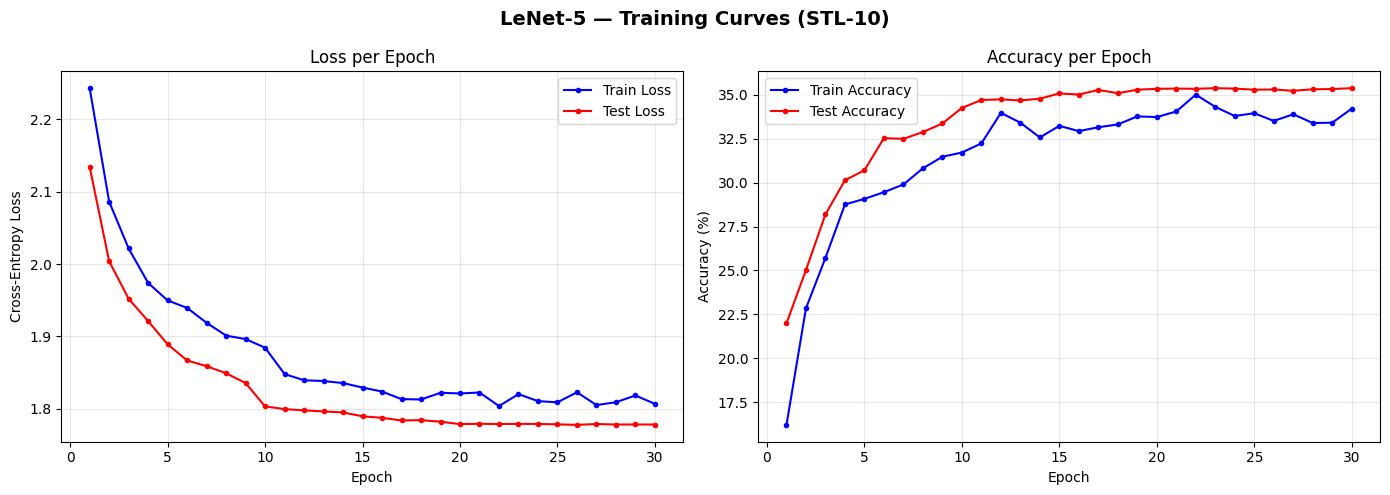

In [4]:
# Plot the notebook training curves for LeNet-5.
plot_lenet_curves(
    history_lenet,
    model_name="LeNet-5",
    save_path="outputs/lenet5_curves_notebook.png",
)

# Save the notebook metrics so they can be reused later.
with open("outputs/lenet5_history_notebook.json", "w") as f:
    json.dump(history_lenet, f, indent=2)

### Interpreting the LeNet-5 baseline

LeNet-5 is expected to learn a stable but limited baseline on STL-10. In this notebook configuration, its role is less about achieving the strongest final score and more about establishing a clear reference point for later comparison.

Typical things to notice in the LeNet results are:

- test accuracy improves steadily early on and then begins to plateau,
- the gap between train and test metrics stays modest, which suggests the model is capacity-limited rather than heavily overfitting, and
- the final performance is useful as a baseline but leaves substantial room for a deeper network.

That plateau is exactly why the ZFNet section matters: it tests whether a larger model with richer inputs can move beyond the ceiling reached by the classic baseline.


## 4. ZFNet

Implementation: **`zfnet.py`**.

ZFNet is the **stronger comparison model** in this project. It keeps more spatial detail by using 64×64 inputs and a deeper stack of convolutional layers, batch normalization, and a larger classifier head. Conceptually, this section asks whether more capacity and higher-resolution inputs produce better STL-10 generalization than the LeNet baseline.

In the next cells, the notebook will:

- build STL-10 loaders resized to 64×64,
- initialize the compact ZFNet-style architecture,
- train it under the project's deeper-model setup, and
- save curves and history so the gains over the baseline can be examined directly.


In [5]:
# Build STL-10 loaders resized to 64x64 for the compact ZFNet-style model.
train_z, test_z = get_stl10_loaders_zfnet(batch_size=BATCH_ZFNET, input_size=64)

# Initialize the model and report its parameter count.
zf = ZFNet(num_classes=NUM_CLASSES, input_size=64).to(device)
count_zf_params(zf)

# Train ZFNet and keep the per-epoch metrics for later plots.
history_zf = train_zfnet(
    zf,
    train_z,
    test_z,
    num_epochs=NUM_EPOCHS_ZFNET,
    model_name="ZFNet (notebook)",
    device=device,
)

[INFO] Training samples : 5000
[INFO] Test samples     : 8000
[INFO] ZFNet pipeline: STL-10 at 64×64.
[INFO] Total trainable parameters: 3,122,506

  Training ZFNet (notebook) on STL-10 (64×64)
  Epochs      : 40
  Batch Size  : 96
  Optimizer   : AdamW (lr=1e-3, wd=1e-4)
  Scheduler   : CosineAnnealingLR
  Device      : cpu

Epoch [  1/40] | Train Loss: 2.2085 | Train Acc: 25.18% | Test Loss: 1.6672 | Test Acc: 35.65% | LR: 0.001000
  [CHECKPOINT] New best test accuracy: 35.65%
  [CHECKPOINT] New best test accuracy: 37.41%
  [CHECKPOINT] New best test accuracy: 40.33%
  [CHECKPOINT] New best test accuracy: 44.00%
Epoch [  5/40] | Train Loss: 1.4818 | Train Acc: 44.12% | Test Loss: 1.3502 | Test Acc: 48.40% | LR: 0.000976
  [CHECKPOINT] New best test accuracy: 48.40%
  [CHECKPOINT] New best test accuracy: 50.05%
  [CHECKPOINT] New best test accuracy: 50.55%
  [CHECKPOINT] New best test accuracy: 52.08%
Epoch [ 10/40] | Train Loss: 1.2018 | Train Acc: 55.24% | Test Loss: 1.2829 | Test A

[INFO] Plot saved to outputs/zfnet_curves_notebook.png


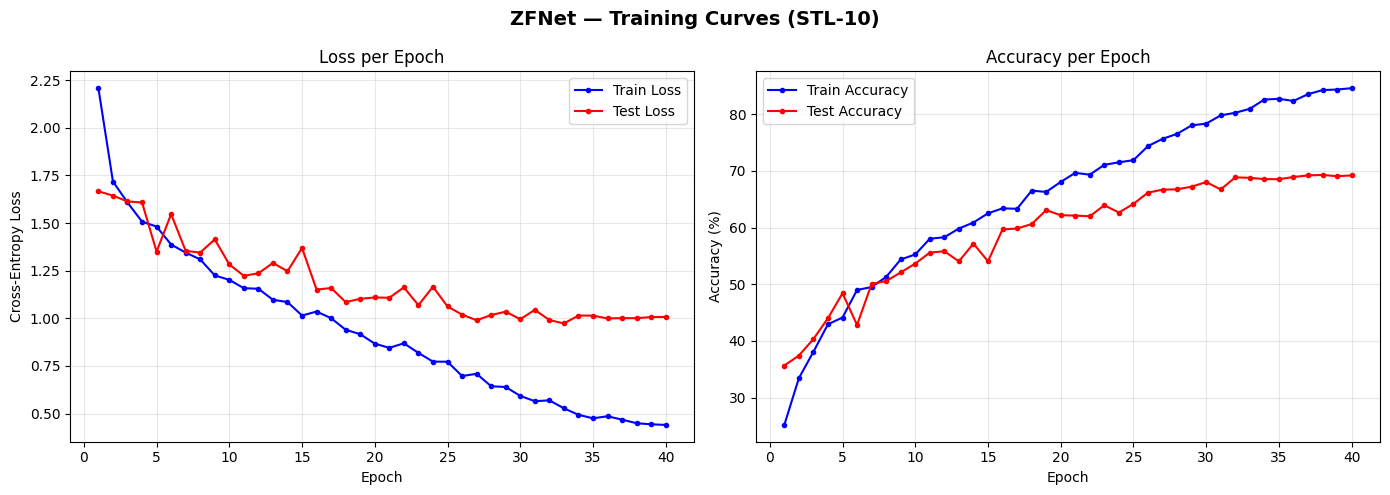

In [6]:
# Plot the notebook training curves for ZFNet.
plot_zf_curves(
    history_zf,
    model_name="ZFNet",
    save_path="outputs/zfnet_curves_notebook.png",
)

# Save the notebook metrics so they can be reused later.
with open("outputs/zfnet_history_notebook.json", "w") as f:
    json.dump(history_zf, f, indent=2)

### Interpreting the ZFNet run

ZFNet should take longer to train than LeNet-5, but the extra depth and the 64×64 input resolution usually pay off in noticeably stronger test performance. In practice, the important pattern is not just the final number, but the fact that ZFNet keeps improving well beyond the point where LeNet has mostly plateaued.

When looking at the saved curves, pay attention to two things:

1. whether test accuracy climbs into a clearly higher band than LeNet-5, and
2. whether the test-loss curve remains meaningfully below the baseline for most of training.

That combination is the evidence that the deeper model is learning more useful visual representations rather than merely fitting the training set harder.


## 5. Model comparison

This section brings the whole project together. After both models have been trained, the next cell overlays their histories so the architectural trade-off is visible in one place instead of being inferred from separate figures.


At this point the notebook has two in-memory histories: one for LeNet-5 and one for ZFNet. The goal here is not to contrast two execution paths, but to compare two **architectural choices** on the same dataset under the same overall project conditions.

This is the cleanest place in the notebook to answer the assignment-level question: *does the deeper ZFNet-style model justify its extra complexity on STL-10?*


[INFO] Comparison plot saved to outputs/comparison_curves_notebook.png


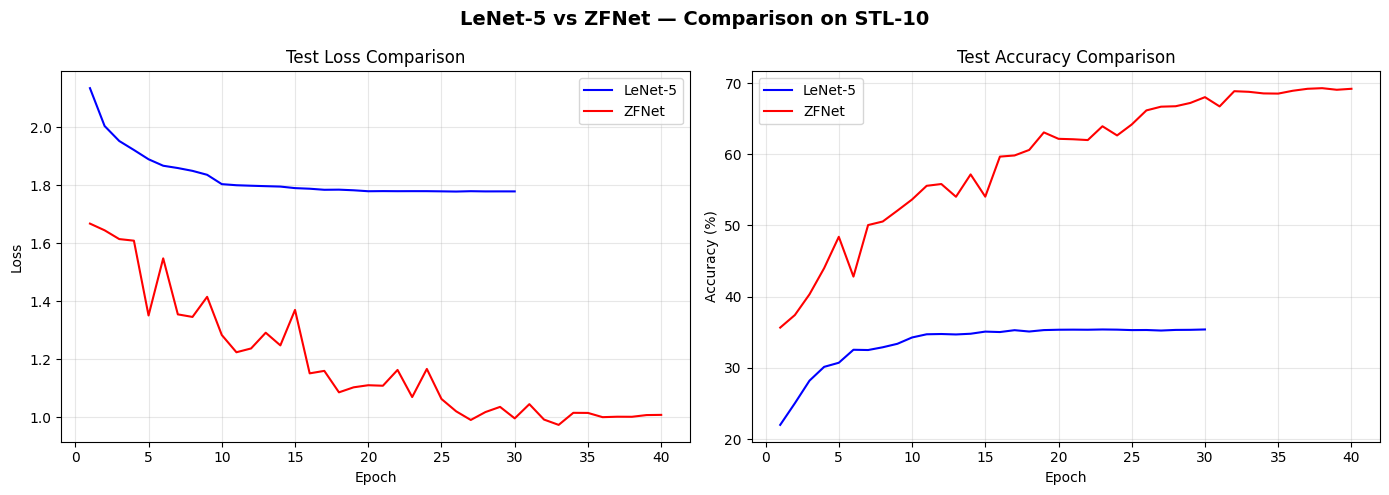

Best test acc — LeNet: 35.3875 | ZFNet: 69.275


In [7]:
# Overlay both model histories to make the architecture trade-off explicit.
compare_architectures(
    history_lenet,
    history_zf,
    save_path="outputs/comparison_curves_notebook.png",
)

# Print a compact summary of the strongest validation-era result from each run.
print(
    "Best test acc — LeNet:",
    max(history_lenet["test_acc"]),
    "| ZFNet:",
    max(history_zf["test_acc"]),
)

### Comparison takeaway

The comparison plot is the most important high-level figure in the notebook because it shows the gap between the two architectures on the **same dataset** under the **same project defaults**.

A useful reading of the figure is:

- **left panel:** does the stronger model consistently achieve lower test loss?
- **right panel:** does the accuracy advantage persist across epochs rather than appearing only briefly?

In this project setup, ZFNet is expected to separate clearly from LeNet-5: the deeper model uses larger inputs and more representational capacity, so it generalizes much better on STL-10 while LeNet remains the lighter baseline.


## 6. Optional: reload saved experiment histories

This section reloads previously saved histories and recreates the comparison plot without retraining.


This section is an optional reproducibility check. Instead of retraining either network, the code below reopens saved metric files and rebuilds the comparison figure directly from disk.

When reading the output, focus on what it means for the project workflow: if the histories load correctly and the plot regenerates, then the experiment record is reusable for reporting, discussion, and later analysis.


[INFO] Comparison plot saved to outputs/comparison_from_main.png


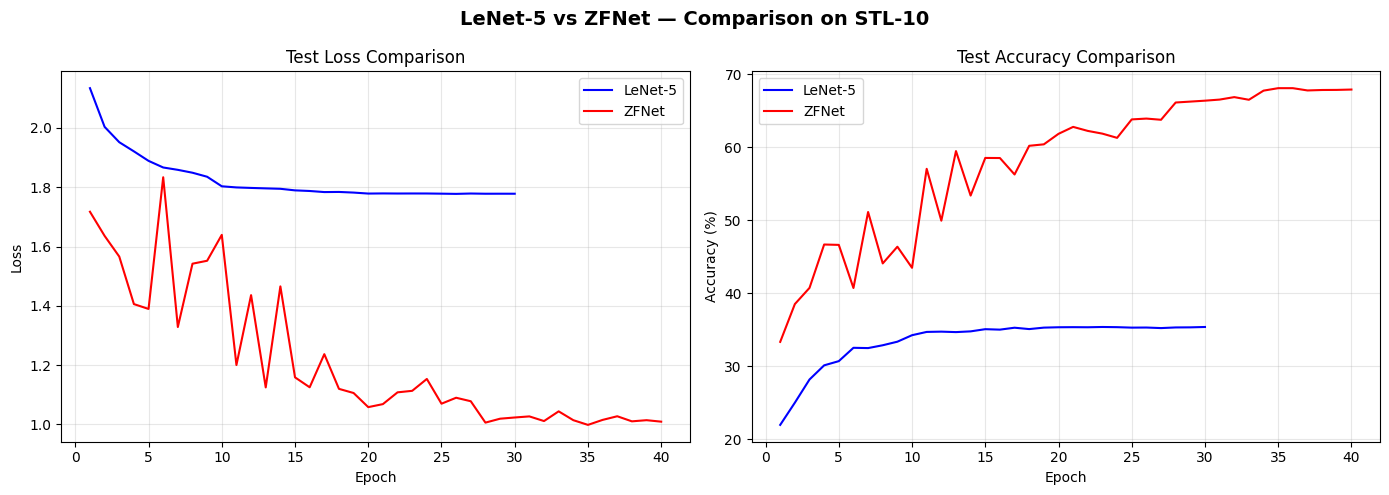

In [8]:
# Reload previously saved histories instead of retraining the models.
with open("outputs/lenet5_history.json") as f:
    h_l = json.load(f)
with open("outputs/zfnet_history.json") as f:
    h_z = json.load(f)

# Rebuild the comparison figure directly from the saved metrics.
compare_architectures(
    h_l,
    h_z,
    save_path="outputs/comparison_from_saved_histories.png",
)

### Why this final section matters

This last step keeps the notebook focused on interpretation instead of repetition. By reusing saved histories, it shows that the project's results can be revisited, replotted, and discussed without rerunning long training jobs.

That makes it useful when:

- you want to review the final curves quickly,
- you are writing up the assignment and need the comparison figure again, or
- you want to verify that the saved experiment record still supports the same conclusions.

If the JSON files are not present yet, generate them first and then return to this cell.
